In [ ]:
import sys
sys.path.append('../src')  #Importing from the src folder

from cosmology import hubble_z
import matplotlib.pyplot as plt
import numpy as np

# Using the parameter values from the paper's OHD row in Table 1
H_values = hubble_z(z_range, q0=-0.553, q1=0.698, H0=69)

plt.figure(figsize=(8, 5))
plt.plot(z_range, H_values, linewidth=2)
plt.xlabel('Redshift (z)')
plt.ylabel('H(z) [km/s/Mpc]')
plt.title('Hubble Parameter vs Redshift\n(q0=-0.55, q1=0.70, H0=69)')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
file_path = r'C:\Users\mriga\Downloads\OHD.txt' #tells python where my file is. Here we use raw string so that backslash doesn't act as an escape character
with open(file_path, 'r') as OHD_data:             #opens and reads inside what's the file, here 'r' means read mode
    content = OHD_data.read()                      #we put the content of that file as a variable named as "content"

print("Here's what's in your file:")
print(content) 

Here's what's in your file:
0.0708	69.0	19.68
0.09	69.0	12.0
0.12	68.6	26.2
0.17	83.0	8.0
0.179	75.0	4.0
0.199	75.0	5.0
0.2	72.9	29.6
0.240	79.69	2.65
0.27	77.0	14.0
0.28	88.8	36.6
0.35	84.4	7.0
0.352	83.0	14.0
0.38	81.2	2.2
0.3802	83.0	14.0
0.4	95	17.0
0.4004	77.0	10.2
0.4247	87.1	11.2
0.43	86.45	3.68
0.44	82.6	7.8
0.4497	92.8	12.9
0.47	89	50
0.4783	80.9	9.0
0.48	97.0	62.0
0.51	90.90	2.1
0.57	92.4	4.5
0.593	104.0	13.0
0.6	87.9	6.1
0.61	98.96	2.2
0.68	92.0	8.0
0.73	97.3	7.0
0.781	105.0	12.0
0.875	125.0	17.0
0.88	90.0	40.0
0.9	117.0	23.0
1.037	154.0	20.0
1.3	168.0	17.0
1.363	160.0	33.6
1.43	177.0	18.0
1.53	140.0	14.0
1.75	202.0	40.0
1.965	186.5	50.4
2.34	222.0	7.0
2.36	226.0	8.0


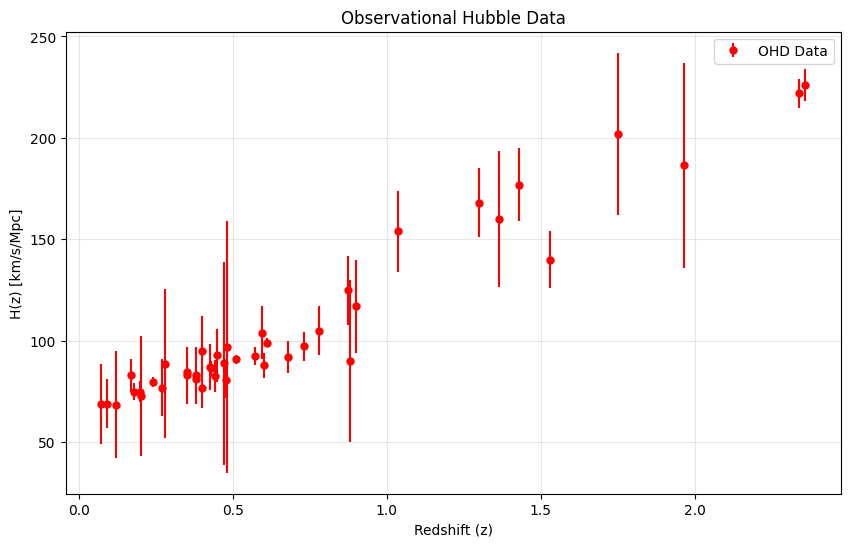

In [28]:
import numpy as np
import matplotlib.pyplot as plt

#Telling Python where to locate our file
file_path = r'C:\Users\mriga\Downloads\OHD.txt'

z_data, H_data, H_err = np.loadtxt(file_path, unpack=True)  #unpack=True will make sure we transpose our data and the columns become arrays instead of rows
 
plt.figure(figsize=(10, 6))   #we want our blank figure to be 10 inches wide and 6 inches tall
plt.errorbar(z_data, H_data, yerr=H_err, fmt='ro', 
             markersize=5, label='OHD Data')   #the circles of the error bars should have size 5 and capsize is to give them caps so they dont look like antennae
plt.xlabel('Redshift (z)')
plt.ylabel('H(z) [km/s/Mpc]')
plt.title('Observational Hubble Data')
plt.grid(True, alpha=0.3)    #we want our grid to be 30% opaque 
plt.legend()
plt.show()

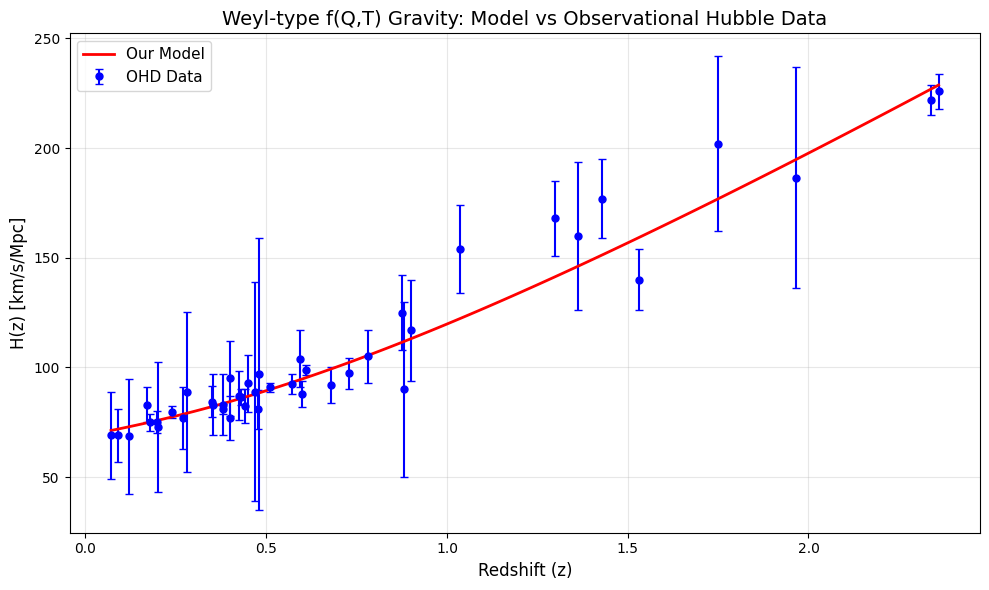

In [32]:
import sys
sys.path.append('../src')

from cosmology import hubble_z
import numpy as np
import matplotlib.pyplot as plt

# Creating the plot again, but now add our model
plt.figure(figsize=(10, 6))

# Plotting the data
file_path = r"C:\Users\mriga\Downloads\OHD.txt"

z_data, H_data, H_err = np.loadtxt(file_path, unpack = True)
plt.errorbar(z_data, H_data, yerr=H_err, fmt='bo', 
             markersize=5, capsize=3, label='OHD Data')

#Plotting our model
z_smooth = np.linspace(0.0708, 2.36, 100)  # 100 points from z=0.0708 to z=2.36
H_model = hubble_z(z_smooth, q0=-0.553, q1=0.698)  #Using the paper's values

plt.plot(z_smooth, H_model, 'r-', linewidth=2, label='Our Model')

plt.xlabel('Redshift (z)', fontsize= 12)
plt.ylabel('H(z) [km/s/Mpc]', fontsize= 12) 
plt.title('Weyl-type f(Q,T) Gravity: Model vs Observational Hubble Data', fontsize=14 )
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show() 

In [24]:
import sys
sys.path.append('../src')

from mcmc_analysis import log_likelihood
import numpy as np

file_path = r'C:\Users\mriga\Downloads\OHD.txt'
z_data, H_data, H_err = np.loadtxt(file_path, unpack=True)

#Testing the function using paper's parameter values (should be a good fit)
test_params1 = [-0.553, 0.698]
likelihood_value1 = log_likelihood(test_params1, z_data, H_data, H_err)
print(f"Likelihood for q0 = {test_params1[0]}, q1 = {test_params1[1]} is: {likelihood_value1:.2f}")

#Testing the function using random parameter values (should be a bad fit)
test_params2 = [1,1]
likelihood_value2 = log_likelihood(test_params2, z_data, H_data, H_err)
print(f"Likelihood for q0 = {test_params2[0]}, q1 = {test_params2[1]} is: {likelihood_value2:.2f}")

Likelihood for q0 = -0.553, q1 = 0.698 is: -12.00
Likelihood for q0 = 1, q1 = 1 is: -64043.79


In [3]:
import sys
sys.path.append('../src')
import numpy as np

from mcmc_analysis import log_posterior
print("Testing the posterior function:")
print("-"*70)

filepath = r'C:\Users\mriga\Downloads\OHD.txt'
z_data, H_data, H_err = np.loadtxt(filepath, unpack = True)

#Testing the function using paper's parameter values (should be a good fit)
test_params1 = [-0.553, 0.698]
posterior_value1 = log_posterior(test_params1, z_data, H_data, H_err)
print(f"Log of the posterior function when q0 = {test_params1[0]}, q1 = {test_params1[1]} is: {posterior_value1:.2f}")

#Testing the function using impossible parameter values 
test_params2 = [-0.9, 0.4]
posterior_value2 = log_posterior(test_params2, z_data, H_data, H_err)
print(f"Log of the posterior function when q0 = {test_params2[0]}, q1 = {test_params2[1]} is: {posterior_value2:.2f}")

#Testing the function using random parameter values (but within the reasonable range)
test_params3 = [-0.7, 0.6]
posterior_value3 = log_posterior(test_params3, z_data, H_data, H_err)
print(f"Log of the posterior function when q0 = {test_params3[0]}, q1 = {test_params3[1]} is: {posterior_value3:.2f}")


Testing the posterior function:
----------------------------------------------------------------------
Log of the posterior function when q0 = -0.553, q1 = 0.698 is: -12.00
Log of the posterior function when q0 = -0.9, q1 = 0.4 is: -inf
Log of the posterior function when q0 = -0.7, q1 = 0.6 is: -74.13


Creating the MCMC Sampler


C:\Users\mriga\AppData\Local\Programs\Python\Python313\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████| 3000/3000 [00:03<00:00, 773.54it/s]


MCMC is complete

MCMC Statistics:
Total number of Samples: 60000
The acceptance fraction is: 0.70955
Sample shape: (3000, 20, 2)
That means there are 3000 steps × 20 walkers × 2 dimensions
The flattened shape is: (60000, 2) and total parameter samples are: 60000

MCMC results
q0 = -0.566 ± 0.040
q1 = 0.684 ± 0.060

Comparison with the Paper (OHD row):
Paper: q0 = -0.553 ± 0.059
Paper: q1 = 0.698 ± 0.092


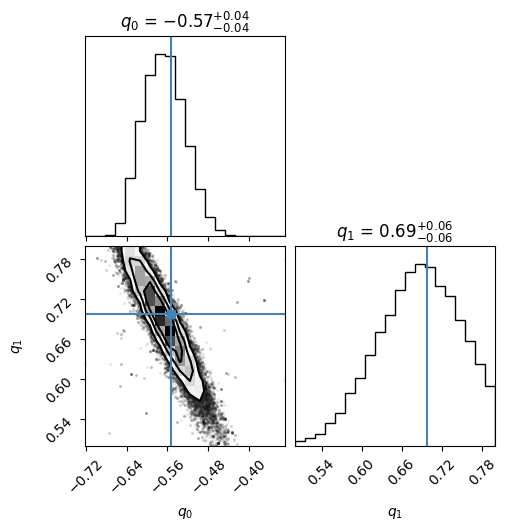

C:\Users\mriga\AppData\Local\Temp\ipykernel_18688\588906918.py:77: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()        #to avoid the subplots from clashing on figure
C:\Users\mriga\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


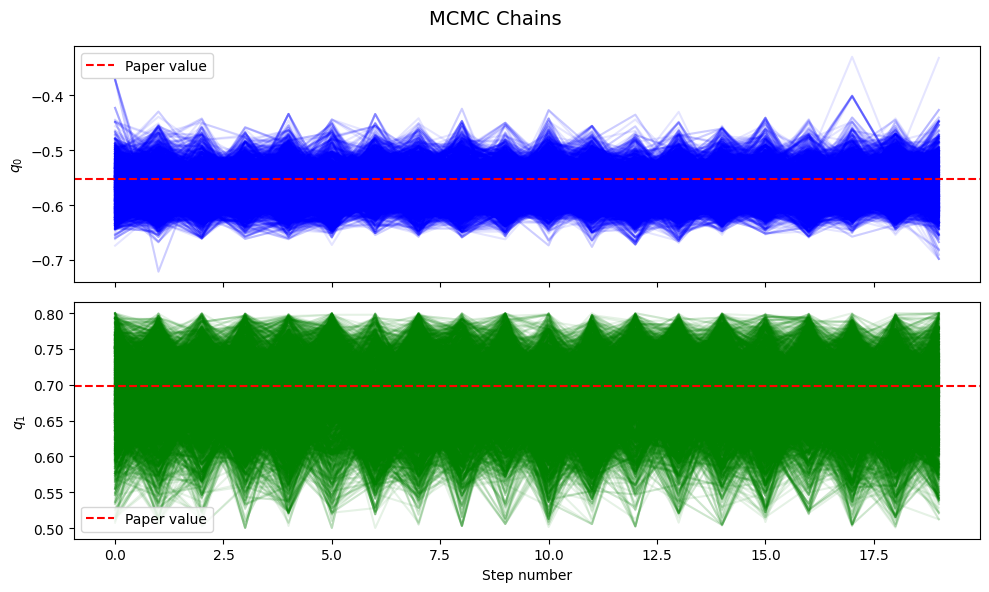

In [4]:
import emcee
import numpy as np
import sys
import tqdm
import corner
import matplotlib.pyplot as plt

sys.path.append('../src')
from mcmc_analysis import log_posterior

filepath = r"C:\Users\mriga\Downloads\OHD.txt"
z_data, H_data, H_err = np.loadtxt(filepath, unpack = True)

#Setting up the MCMC (hyperparameters)
no_of_walkers = 20
no_of_dim = 2
no_of_steps = 3000

#Starting positions of the walkers will be scattered around the paper's values 
starting_guess = np.array([-0.553, 0.698])
starting_positions = starting_guess + 0.1*np.random.randn(no_of_walkers, no_of_dim)   #random.randn will give random numbers from a standard normal distribution

print("Creating the MCMC Sampler")
sampler = emcee.EnsembleSampler(no_of_walkers, no_of_dim, log_posterior, args = (z_data, H_data, H_err)) 
sampler.run_mcmc(starting_positions, no_of_steps, progress = True)
print("MCMC is complete")
print("\nMCMC Statistics:")

#Finding the total number of samples and the Goodman & Weare algorithm acceptance fraction
print(f"Total number of Samples: {no_of_walkers * no_of_steps}")
print(f"The acceptance fraction is: {np.mean(sampler.acceptance_fraction)}")

samples = sampler.get_chain()   #gives the entire history of each walker's path 

print(f"Sample shape: {samples.shape}")    #gives  the shape of the 3D tensor that get_chain() gives us
print(f"That means there are {samples.shape[0]} steps × {samples.shape[1]} walkers × {samples.shape[2]} dimensions")

flat_samples = sampler.flatchain   #flattens the 3D tensor to a 2D array so we can actually do numerical operations with it where there are 60,000 rows(samples)
print(f"The flattened shape is: {flat_samples.shape} and total parameter samples are: {flat_samples.shape[0]}")


q0_mean = np.mean(flat_samples[:,0])
q1_mean = np.mean(flat_samples[:,1])
q0_std = np.std(flat_samples[:,0])
q1_std = np.std(flat_samples[:,1])

print("\nMCMC results")
print(f"q0 = {q0_mean:.3f} ± {q0_std:.3f}")
print(f"q1 = {q1_mean:.3f} ± {q1_std:.3f}")
print("\nComparison with the Paper (OHD row):")
print(f"Paper: q0 = -0.553 ± 0.059")
print(f"Paper: q1 = 0.698 ± 0.092")

#Creating the corner plot (a plot whose 1D marginals give the posterior distributions of each parameter and the off diagonal gives the posterior distributions of two parameters)
fig = corner.corner(flat_samples, labels = [r"$q_0$", r"$q_1$"], truths = [-0.553, 0.698], show_titles = True, title_kwargs= {"fontsize":12})
plt.show()



# Plotting the MCMC chains to check convergence (i.e. whether the Markov chains are generating samples from the target distribution unbiased to the burn-in)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True) 

# Plotting the MCMC chains history of the parameter q0
axes[0].plot(samples[:, :, 0].T, alpha=0.1, color='blue')
axes[0].set_ylabel(r"$q_0$")
axes[0].axhline(y=-0.553, color='red', linestyle='--', label='Paper value')

# Plotting the MCMC chains history of the parameter q1  
axes[1].plot(samples[:, :, 1].T, alpha=0.1, color='green')
axes[1].set_ylabel(r"$q_1$")
axes[1].set_xlabel("Step number")
axes[1].axhline(y=0.698, color='red', linestyle='--', label='Paper value')

axes[0].legend()
axes[1].legend()
plt.suptitle("MCMC Chains", fontsize=14)    #Super title
plt.tight_layout()        #to avoid the subplots from clashing on figure
plt.show()

Loaded 1048 Pantheon supernovae
Redshift range: 0.010 to 2.260
mb range: 13.91 to 26.88

First 5 rows:
z=0.503, mb=22.93±0.126
z=0.495, mb=22.88±0.118
z=0.678, mb=24.04±0.206
z=0.867, mb=24.35±0.174
z=0.799, mb=24.36±0.174

Test with q0=-0.553, q1=0.698, M_B=-19.35:
χ² = 1106.06
log-likelihood = -553.03
Reduced χ² = 1.055


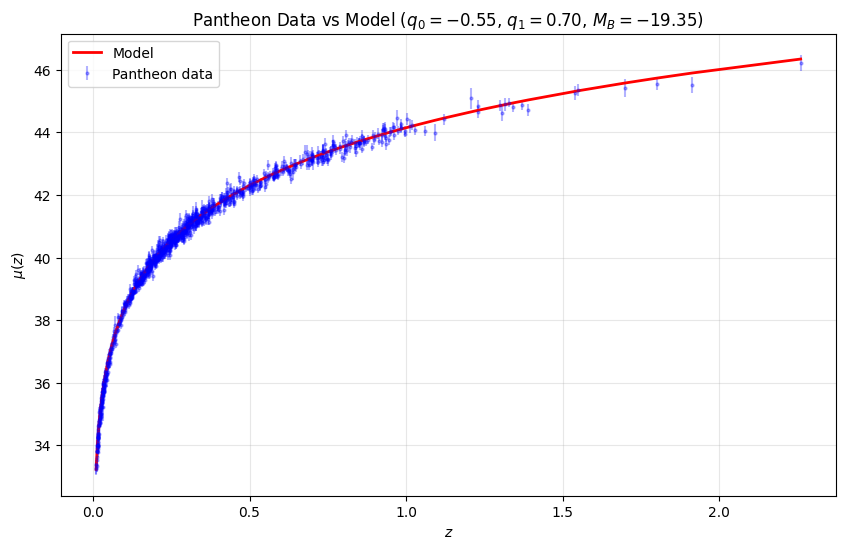


Testing priors:
Good params: 0.0
Bad q0: -inf
Bad M_B: -inf
Running joint MCMC


C:\Users\mriga\AppData\Local\Programs\Python\Python313\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████████████████████████████████| 3000/3000 [33:29<00:00,  1.49it/s]



JOINT MCMC RESULTS (OHD + Pantheon)
q₀ = -0.568 ± 0.028
q₁ = 0.697 ± 0.048
M_B = -19.388 ± 0.007

Comparison with Paper (Table 1, Joint column):
Paper: q₀ = -0.611 ± 0.051
Paper: q₁ = 0.66 ± 0.087


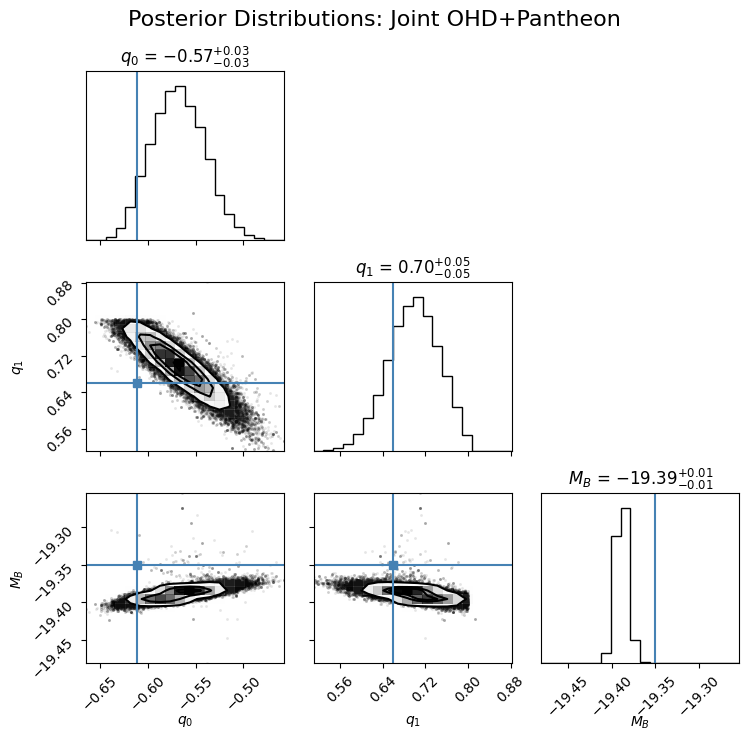

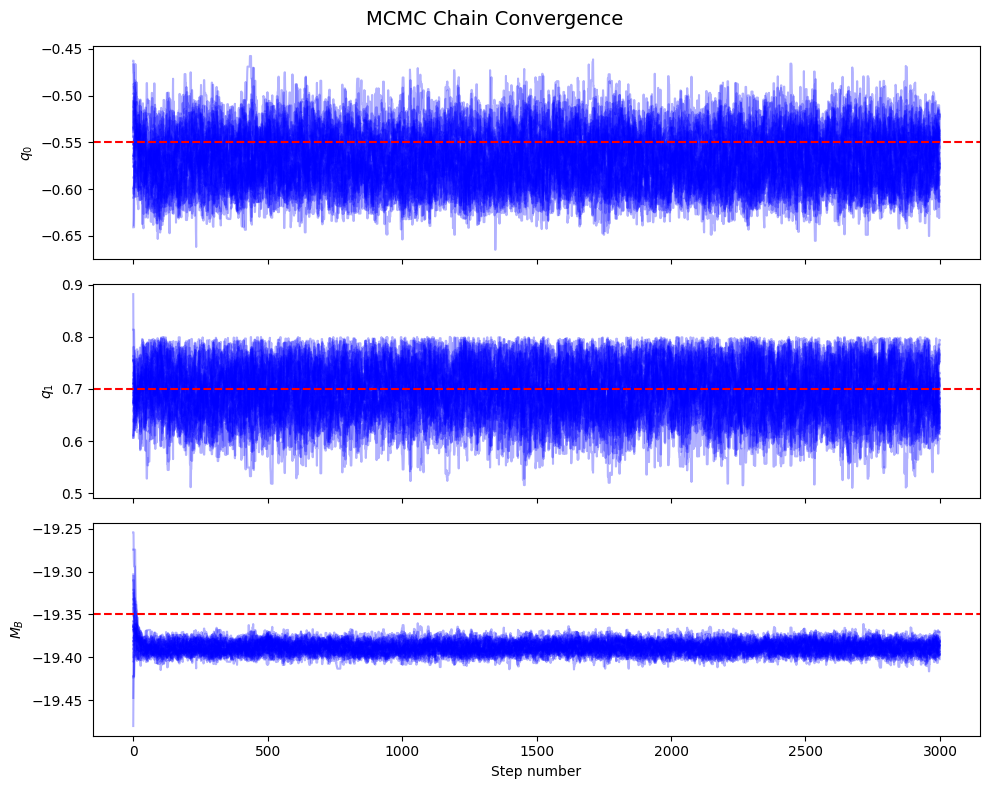

In [9]:
#Testing the Pantheon setup
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

import sys
sys.path.append('../src')

from cosmology import distance_modulus_theory
from mcmc_analysis import chi2_SNeIa, log_likelihood_SNeIa, log_likelihood_combined,  log_posterior_combined


data_ohd = np.loadtxt(r"C:\Users\mriga\Downloads\OHD.txt")
z_ohd = data_ohd[:, 0]
H_ohd = data_ohd[:, 1]
H_err = data_ohd[:, 2]

data_SNeIa = np.loadtxt(r"C:\Users\mriga\Downloads\Pantheon_1048.txt")
zcmb = data_SNeIa[:, 0]      # First column: CMB-frame redshift
mb = data_SNeIa[:, 3]        # Fourth column: apparent magnitude  
dmb = data_SNeIa[:, 4]       # Fifth column: magnitude error

print(f"Loaded {len(zcmb)} Pantheon supernovae")
print(f"Redshift range: {zcmb.min():.3f} to {zcmb.max():.3f}")
print(f"mb range: {mb.min():.2f} to {mb.max():.2f}")
print("\nFirst 5 rows:")
for i in range(5):
    print(f"z={zcmb[i]:.3f}, mb={mb[i]:.2f}±{dmb[i]:.3f}")

# 2. Testing with paper's parameters + typical M_B value
test_params = [-0.553, 0.698, -19.35]  # q0, q1, M_B (choosing the fiducial value of M_B from Scolnic et al. (2018))

# Calculating chi2
chi2_sn = chi2_SNeIa(test_params, zcmb, mb, dmb)   #calculates the value of chi squared for every value of zcmb, mb, and dmb in each row 
logL_sn = log_likelihood_SNeIa(test_params, zcmb, mb, dmb)

print(f"\nTest with q0={test_params[0]}, q1={test_params[1]}, M_B={test_params[2]}:")
print(f"χ² = {chi2_sn:.2f}")
print(f"log-likelihood = {logL_sn:.2f}")
print(f"Reduced χ² = {chi2_sn/len(zcmb):.3f}")

#Plotting the data vs model
mu_model = distance_modulus_theory(zcmb, test_params[0], test_params[1], H0=70)  #Finding the expected distance modulus
mu_obs = mb - test_params[2]  #Finding the observed distance modulus

plt.figure(figsize=(10, 6))
plt.errorbar(zcmb, mu_obs, yerr=dmb, fmt='bo', markersize=2, alpha=0.3, label='Pantheon data')
plt.plot(np.sort(zcmb), distance_modulus_theory(np.sort(zcmb), test_params[0], test_params[1], H0=70), 
         'r-', linewidth=2, label='Model')
plt.xlabel(r'$z$')
plt.ylabel(r'$μ(z)$')
plt.title(r"Pantheon Data vs Model ($q_{0}=-0.55$, $q_{1}=0.70$, $M_{B}=-19.35$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Checking if the priors priors work
from mcmc_analysis import log_prior_SNeIa

print("\nTesting priors:")
test_good = [-0.55, 0.70, -19.3]
test_bad_q0 = [0.0, 0.70, -19.3]  # q0 too high
test_bad_MB = [-0.55, 0.70, -30.0]  # M_B too low

print(f"Good params: {log_prior_SNeIa(test_good)}")
print(f"Bad q0: {log_prior_SNeIa(test_bad_q0)}") 
print(f"Bad M_B: {log_prior_SNeIa(test_bad_MB)}")



# Setting up the hyperparameters for MCMC analysis of joint OHD + Pantheon data
no_of_walkers = 32
no_of_dim = 3  # q0, q1, M_B
no_of_steps = 3000

# For starting positions, we will use the paper values
starting_guess = np.array([-0.55, 0.70, -19.35])
starting_positions = starting_guess + 0.05 * np.random.randn(no_of_walkers, no_of_dim)

# Create sampler
sampler = emcee.EnsembleSampler(no_of_walkers, no_of_dim, log_posterior_combined, args=(z_ohd, H_ohd, H_err, zcmb, mb, dmb))

print("Running joint MCMC")
sampler.run_mcmc(starting_positions, n_steps, progress=True)

samples = sampler.get_chain()  #to get the history of each walker's path
flat_samples = sampler.flatchain   #flattens the 3D tensor to a 2D array so we can actually do numerical operations with it where there are 60,000 rows(samples)

# Calculating means and standard deviations
q0_mean = np.mean(flat_samples[:, 0])
q0_std = np.std(flat_samples[:, 0])
q1_mean = np.mean(flat_samples[:, 1])
q1_std = np.std(flat_samples[:, 1])
MB_mean = np.mean(flat_samples[:, 2])
MB_std = np.std(flat_samples[:, 2])

print("\n" + "="*50)
print("JOINT MCMC RESULTS (OHD + Pantheon)")
print("="*50)
print(f"q₀ = {q0_mean:.3f} ± {q0_std:.3f}")
print(f"q₁ = {q1_mean:.3f} ± {q1_std:.3f}")
print(f"M_B = {MB_mean:.3f} ± {MB_std:.3f}")
print("\nComparison with Paper (Table 1, Joint column):")
print(f"Paper: q₀ = -0.611 ± 0.051")
print(f"Paper: q₁ = 0.66 ± 0.087")

# Now we shall find the corner plot
fig = corner.corner( flat_samples, labels=[r"$q_0$", r"$q_1$", r"$M_B$"], truths=[-0.611, 0.66, -19.35], show_titles=True, title_kwargs={"fontsize": 12})
plt.suptitle("Posterior Distributions: Joint OHD+Pantheon", fontsize=16)
plt.tight_layout()
plt.show()

# Chain convergence plot
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
samples = sampler.get_chain()

labels = [r"$q_0$", r"$q_1$", r"$M_B$"]
for i, ax in enumerate(axes):
    ax.plot(samples[:, :, i], alpha=0.3, color='blue')
    ax.set_ylabel(labels[i])
    ax.axhline(y=starting_guess[i], color='red', linestyle='--', label='Starting value')
    
axes[-1].set_xlabel("Step number")
plt.suptitle("MCMC Chain Convergence", fontsize=14)
plt.tight_layout()
plt.show()

Creating the MCMC Sampler


C:\Users\mriga\AppData\Local\Programs\Python\Python313\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████████████████████████████████| 3000/3000 [31:28<00:00,  1.59it/s]


MCMC is complete

MCMC Statistics:
Total number of Samples: 96000
The acceptance fraction is: 0.6055416666666666
Sample shape: (3000, 32, 3)
That means there are 3000 steps × 32 walkers × 3 dimensions
The flattened shape is: (96000, 3) and total parameter samples are: 96000


SNeIa Results
q0 = -0.563 ± 0.031
q1 = 0.717 ± 0.066
M_B = -19.386 ± 0.008

Comparison with the Paper (SNeIa row):
Paper: q0 = -0.688 ± 0.054
Paper: q1 = 0.635 ± 0.094 


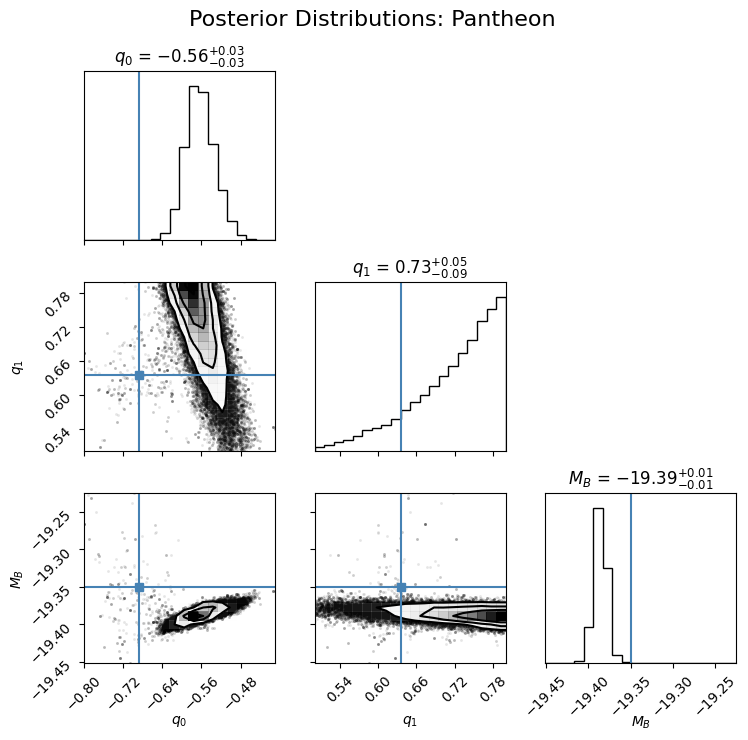

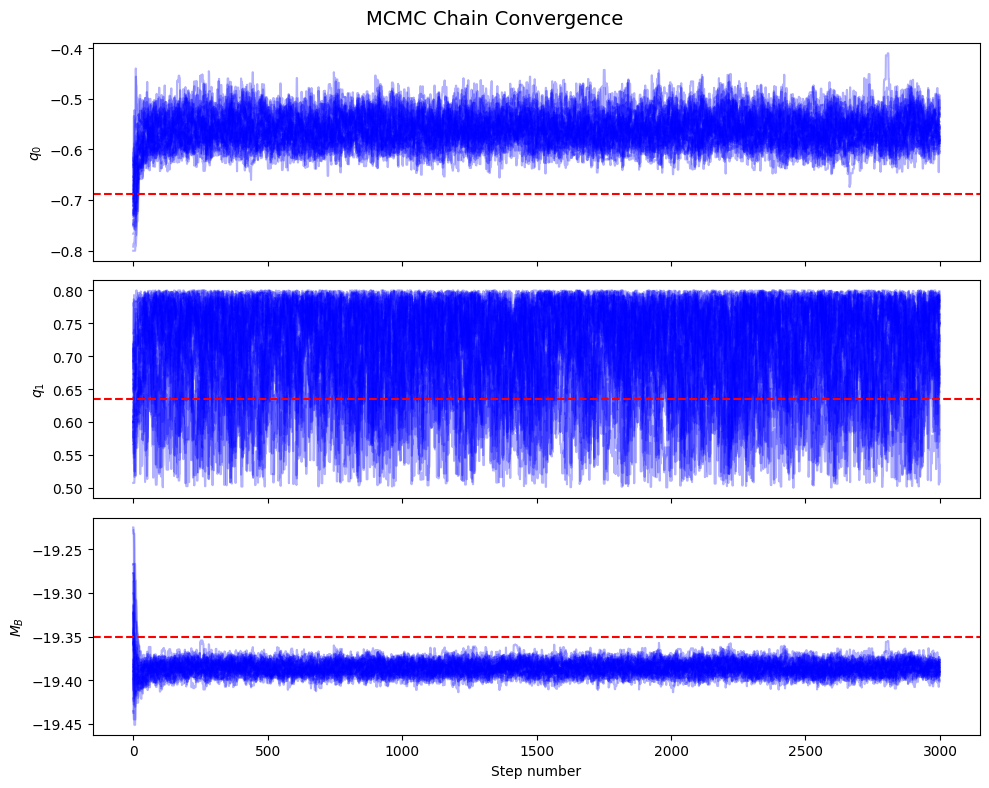

In [4]:
import emcee
import numpy as np
import sys
import tqdm
import corner
import matplotlib.pyplot as plt

sys.path.append('../src')

from mcmc_analysis import chi2_SNeIa, log_likelihood_SNeIa, log_posterior_SNeIa


data_SNeIa = np.loadtxt(r"C:\Users\mriga\Downloads\Pantheon_1048.txt")
zcmb = data_SNeIa[:, 0]      # First column: CMB-frame redshift
mb = data_SNeIa[:, 3]        # Fourth column: apparent magnitude  
dmb = data_SNeIa[:, 4]       # Fifth column: magnitude error

#Setting up the MCMC (hyperparameters)
no_of_walkers = 32
no_of_dim = 3
no_of_steps = 3000


# 2. Testing with paper's parameters + typical M_B value
test_params = [-0.553, 0.698, -19.35]  # q0, q1, M_B (choosing the fiducial value of M_B from Scolnic et al. (2018))

starting_guess = np.array([-0.688, 0.635, -19.35])
starting_positions = starting_guess + 0.05 * np.random.randn(no_of_walkers, no_of_dim)

print("Creating the MCMC Sampler")
sampler = emcee.EnsembleSampler(no_of_walkers, no_of_dim, log_posterior_SNeIa, args = (zcmb,mb,dmb)) 
sampler.run_mcmc(starting_positions, no_of_steps, progress = True)
print("MCMC is complete")
print("\nMCMC Statistics:")

#Finding the total number of samples and the Goodman & Weare algorithm acceptance fraction
print(f"Total number of Samples: {no_of_walkers * no_of_steps}")
print(f"The acceptance fraction is: {np.mean(sampler.acceptance_fraction)}")

samples = sampler.get_chain()   #gives the entire history of each walker's path 

print(f"Sample shape: {samples.shape}")    #gives  the shape of the 3D tensor that get_chain() gives us
print(f"That means there are {samples.shape[0]} steps × {samples.shape[1]} walkers × {samples.shape[2]} dimensions")

flat_samples = sampler.flatchain   
print(f"The flattened shape is: {flat_samples.shape} and total parameter samples are: {flat_samples.shape[0]}")


#Calculating means and standard deviations
q0_mean = np.mean(flat_samples[:, 0])
q0_std = np.std(flat_samples[:, 0])
q1_mean = np.mean(flat_samples[:, 1])
q1_std = np.std(flat_samples[:, 1])
MB_mean = np.mean(flat_samples[:, 2])
MB_std = np.std(flat_samples[:, 2])

print("\n" + "="*50)
print("\nSNeIa Results")
print(f"q0 = {q0_mean:.3f} ± {q0_std:.3f}")
print(f"q1 = {q1_mean:.3f} ± {q1_std:.3f}")
print(f"M_B = {MB_mean:.3f} ± {MB_std:.3f}")
print("\nComparison with the Paper (SNeIa row):")
print(f"Paper: q0 = -0.688 ± 0.054")
print(f"Paper: q1 = 0.635 ± 0.094 ")

#Creating the corner plot (a plot whose 1D marginals give the posterior distributions of each parameter and the off diagonal gives the posterior distributions of two parameters)
fig = corner.corner(flat_samples, labels = [r"$q_0$", r"$q_1$", r"$M_B$"], truths = [-0.688, 0.635, -19.35], show_titles = True, title_kwargs= {"fontsize":12})
plt.suptitle("Posterior Distributions: Pantheon", fontsize=16)
plt.tight_layout()
plt.show()



# Plotting the MCMC chains to check convergence (i.e. whether the Markov chains are generating samples from the target distribution unbiased to the burn-in)
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
samples = sampler.get_chain()

labels = [r"$q_0$", r"$q_1$", r"$M_B$"]
for i, ax in enumerate(axes):
    ax.plot(samples[:, :, i], alpha=0.3, color='blue')
    ax.set_ylabel(labels[i])
    ax.axhline(y=starting_guess[i], color='red', linestyle='--', label='Starting value')
    
axes[-1].set_xlabel("Step number")
plt.suptitle("MCMC Chain Convergence", fontsize=14)
plt.tight_layout()
plt.show()